In [1]:
from random import sample

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install nlp


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Load from Parquet
# jobs_df_cleaned = pd.read_parquet("jobs_df_with_entities.parquet", engine="pyarrow")
# cvs_df_cleaned = pd.read_parquet("cvs_df_with_entities.parquet", engine="pyarrow")
# print(jobs_df_cleaned.shape, cvs_df_cleaned.shape)
df_temp_jobs_df_cleaned = pd.read_parquet("jobs_df_with_entities.parquet", engine="pyarrow")
df_temp = pd.read_parquet("cvs_df_with_entities.parquet", engine="pyarrow")
df_temp = df_temp.reset_index(drop=True)

In [4]:
df_temp_jobs_df_cleaned = df_temp_jobs_df_cleaned.reset_index(drop=True)

In [5]:
df_temp_jobs_df_cleaned.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,...,Long Description_tokens,Primary Keyword_tokens,Position_tokens,Long Description_lemmatized,Primary Keyword_lemmatized,Position_lemmatized,Long Description_lemmatized_nostop,Primary Keyword_lemmatized_nostop,Position_lemmatized_nostop,Extracted Entities
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,...,"[requirements, were, looking, for, a, long, te...",[sysadmin],"[10, blockchain, nodes, masternodes, to, set, up]","[requirement, be, look, for, a, long, term, co...",[sysadmin],"[10, blockchain, node, masternodes, to, set, up]","[requirement, look, long, term, collaboration,...",[sysadmin],"[10, blockchain, node, masternodes, set]","{'CARDINAL': None, 'DATE': None, 'EVENT': None..."
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,...,"[greetings, my, name, is, maria, i, am, in, ur...",[net],"[10, net, developers, middle, and, senior, level]","[greeting, my, name, be, maria, i, be, in, urg...",[net],"[10, net, developer, middle, and, senior, level]","[greeting, name, maria, urgent, need, find, te...",[net],"[10, net, developer, middle, senior, level]","{'CARDINAL': ['10', '30005000', '9'], 'DATE': ..."
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,...,"[product, the, product, is, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, the, product, be, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, product, live, video, chat, cobrowsi...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","{'CARDINAL': ['7', '11', '15', '14', '4', '14'..."
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,...,"[currently, tcm, expanding, its, activities, t...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, it, activity, to, ukr...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, activity, ukraine, hi...",[marketing],"[16, amazon, brand, manager]","{'CARDINAL': ['zero'], 'DATE': ['daily', '2 ye..."
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,...,"[hello, we, mimirb2b, are, an, outstaff, compa...",[marketing],"[16, amazon, brand, manager]","[hello, we, mimirb2b, be, an, outstaff, compan...",[marketing],"[16, amazon, brand, manager]","[hello, mimirb2b, outstaff, company, look, exp...",[marketing],"[16, amazon, brand, manager]","{'CARDINAL': ['zero'], 'DATE': ['daily', '2 ye..."


In [6]:
df_temp_jobs_df_cleaned.shape

(141897, 25)

In [11]:
df_temp_jobs_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141897 entries, 0 to 141896
Data columns (total 27 columns):
 #   Column                              Non-Null Count   Dtype              
---  ------                              --------------   -----              
 0   Position                            141897 non-null  object             
 1   Long Description                    141897 non-null  object             
 2   Company Name                        141897 non-null  object             
 3   Exp Years                           141897 non-null  object             
 4   Primary Keyword                     141897 non-null  object             
 5   English Level                       141897 non-null  object             
 6   Published                           141897 non-null  datetime64[ns, UTC]
 7   Long Description_lang               141897 non-null  object             
 8   id                                  141897 non-null  object             
 9   __index_level_0__         

In [12]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210207 entries, 0 to 210206
Data columns (total 34 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Position                           210207 non-null  object 
 1   Moreinfo                           210207 non-null  object 
 2   Looking For                        210207 non-null  object 
 3   Highlights                         210207 non-null  object 
 4   Primary Keyword                    210207 non-null  object 
 5   English Level                      210207 non-null  object 
 6   Experience Years                   210207 non-null  float64
 7   CV                                 210207 non-null  object 
 8   CV_lang                            210207 non-null  object 
 9   id                                 210207 non-null  object 
 10  __index_level_0__                  210207 non-null  int64  
 11  Primary Keyword Normalized         2102

Outlier Detection for Experience Years:


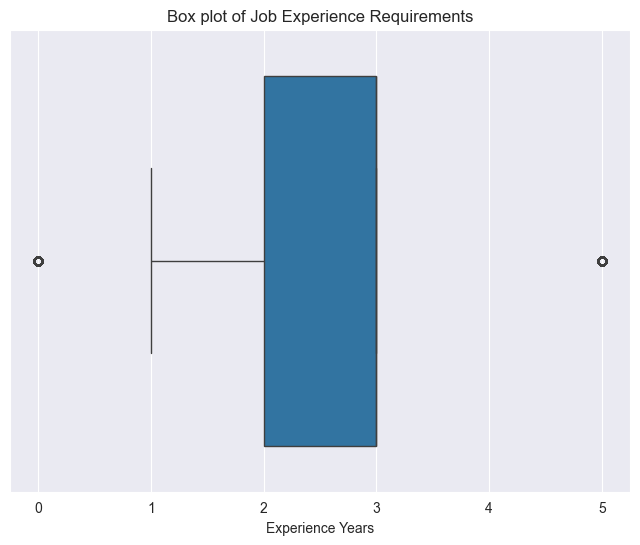

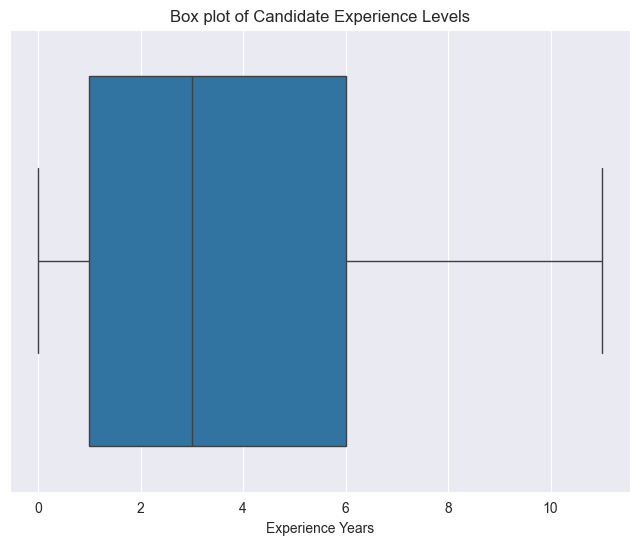


Job Experience Outliers (IQR method):
  IQR: 1.0
  Lower Bound: 0.5
  Upper Bound: 4.5
  Number of outliers: 33744
  Percentage of outliers: 23.78%

Candidate Experience Outliers (IQR method):
  IQR: 5.0
  Lower Bound: -6.5
  Upper Bound: 13.5
  Number of outliers: 0
  Percentage of outliers: 0.00%

Schema Consistency Check:
Columns in df_temp_jobs_df_cleaned: ['Position', 'Long Description', 'Company Name', 'Exp Years', 'Primary Keyword', 'English Level', 'Published', 'Long Description_lang', 'id', '__index_level_0__', 'Primary Keyword Normalized', 'Company Name Normalized', 'Position Normalized', 'posting_year', 'posting_month', 'Long Description_tokens', 'Primary Keyword_tokens', 'Position_tokens', 'Long Description_lemmatized', 'Primary Keyword_lemmatized', 'Position_lemmatized', 'Long Description_lemmatized_nostop', 'Primary Keyword_lemmatized_nostop', 'Position_lemmatized_nostop', 'Extracted Entities', 'Exp Years Cleaned', 'job_text']
Columns in df_temp: ['Position', 'Moreinfo',

,Position Normalized,Primary Keyword Normalized,Long Description,job_text
0,10 blockchain nodes masternodes to set up,system administrator,requirements were looking for a long term coll...,10 blockchain nodes masternodes to set up syst...
1,10 net developers middle and senior level,.net,greetings my name is maria i am in urgent need...,10 net developers middle and senior level .net...
2,10x engineer cofounder 4 employee usd 1112k 14...,javascript,product the product is a live video chat and c...,10x engineer cofounder 4 employee usd 1112k 14...
3,16 amazon brand manager,marketing,currently tcm expanding its activities to ukra...,16 amazon brand manager marketing currently tc...
4,16 amazon brand manager,marketing,hello we mimirb2b are an outstaff company and ...,16 amazon brand manager marketing hello we mim...



Sample of cvs_df_cleaned with 'candidate_text':


,Position Normalized,Primary Keyword Normalized,Moreinfo,CV,candidate_text
0,cto vp of software development,lead,who am i 13 years of commercial experience as ...,landed a role of director of blockchain develo...,cto vp of software development lead who am i 1...
1,10x engineer cofounder 4 employee usd 1112k 14...,other,worked on a mobile application for tracking trips,worked on a mobile application for tracking trips,10x engineer cofounder 4 employee usd 1112k 14...
2,10x engineer cofounder 4 employee usd 1112k 14...,flutter,1 am an 1c developer i deployed an 1c to typog...,1 am an 1c developer i deployed an 1c to typog...,10x engineer cofounder 4 employee usd 1112k 14...
3,10x engineer cofounder 4 employee usd 1112k 14...,other,perfect knowledge of 1centerprise platform goo...,perfect knowledge of 1centerprise platform goo...,10x engineer cofounder 4 employee usd 1112k 14...
4,accountingimmigration support specialist,support,tech addicted experienced customer support wit...,thousands of resolved problems also thousands ...,accountingimmigration support specialist suppo...


In [9]:
def clean_experience(val):
    if isinstance(val, str):
        if val.endswith('y'):
            return float(val.replace('y', ''))
        elif val.lower() == 'no_exp':
            return 0.0
    return np.nan  # fallback for unexpected formats


df_temp_jobs_df_cleaned['Exp Years Cleaned'] = df_temp_jobs_df_cleaned['Exp Years'].apply(clean_experience)
df_temp['Experience Years Cleaned'] = df_temp['Experience Years'].apply(clean_experience)
# 1. Outlier Detection for Experience Years
print("Outlier Detection for Experience Years:")

# Box plot for 'Exp Years Numerical' in jobs_df_cleaned
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_temp_jobs_df_cleaned['Exp Years Cleaned'])
plt.title('Box plot of Job Experience Requirements')
plt.xlabel('Experience Years')
plt.show()

# Box plot for 'Experience Years' in cvs_df_cleaned
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_temp['Experience Years'])
plt.title('Box plot of Candidate Experience Levels')
plt.xlabel('Experience Years')
plt.show()

# You can also use statistical methods to identify outliers, e.g., using IQR
Q1_jobs = df_temp_jobs_df_cleaned['Exp Years Cleaned'].quantile(0.25)
Q3_jobs = df_temp_jobs_df_cleaned['Exp Years Cleaned'].quantile(0.75)
IQR_jobs = Q3_jobs - Q1_jobs
lower_bound_jobs = Q1_jobs - 1.5 * IQR_jobs
upper_bound_jobs = Q3_jobs + 1.5 * IQR_jobs

print(f"\nJob Experience Outliers (IQR method):")
print(f"  IQR: {IQR_jobs}")
print(f"  Lower Bound: {lower_bound_jobs}")
print(f"  Upper Bound: {upper_bound_jobs}")
outliers_jobs = df_temp_jobs_df_cleaned[(df_temp_jobs_df_cleaned['Exp Years Cleaned'] < lower_bound_jobs) | (
            df_temp_jobs_df_cleaned['Exp Years Cleaned'] > upper_bound_jobs)]
print(f"  Number of outliers: {outliers_jobs.shape[0]}")
print(f"  Percentage of outliers: {outliers_jobs.shape[0] / df_temp_jobs_df_cleaned.shape[0] * 100:.2f}%")

Q1_cvs = df_temp['Experience Years'].quantile(0.25)
Q3_cvs = df_temp['Experience Years'].quantile(0.75)
IQR_cvs = Q3_cvs - Q1_cvs
lower_bound_cvs = Q1_cvs - 1.5 * IQR_cvs
upper_bound_cvs = Q3_cvs + 1.5 * IQR_cvs

print(f"\nCandidate Experience Outliers (IQR method):")
print(f"  IQR: {IQR_cvs}")
print(f"  Lower Bound: {lower_bound_cvs}")
print(f"  Upper Bound: {upper_bound_cvs}")
outliers_cvs = df_temp[
    (df_temp['Experience Years'] < lower_bound_cvs) | (df_temp['Experience Years'] > upper_bound_cvs)]
print(f"  Number of outliers: {outliers_cvs.shape[0]}")
print(f"  Percentage of outliers: {outliers_cvs.shape[0] / df_temp.shape[0] * 100:.2f}%")

# 2. Schema Consistency Check
print("\nSchema Consistency Check:")

# Compare columns
print(f"Columns in df_temp_jobs_df_cleaned: {list(df_temp_jobs_df_cleaned.columns)}")
print(f"Columns in df_temp: {list(df_temp.columns)}")

# Check for common columns (excluding index columns if any were kept)
common_cols = list(set(df_temp_jobs_df_cleaned.columns) & set(df_temp.columns))
print(f"\nCommon columns: {common_cols}")

# Check for columns only in jobs_df_cleaned
cols_only_in_jobs = list(set(df_temp_jobs_df_cleaned.columns) - set(df_temp.columns))
print(f"Columns only in df_temp_jobs_df_cleaned: {cols_only_in_jobs}")

# Check for columns only in cvs_df_cleaned
cols_only_in_cvs = list(set(df_temp.columns) - set(df_temp_jobs_df_cleaned.columns))
print(f"Columns only in df_temp: {cols_only_in_cvs}")

# Compare data types for common columns
print("\nData Type Consistency for Common Columns:")
for col in common_cols:
    dtype_jobs = df_temp_jobs_df_cleaned[col].dtype
    dtype_cvs = df_temp[col].dtype
    print(f"  '{col}': df_temp_jobs_df_cleaned dtype = {dtype_jobs}, df_temp dtype = {dtype_cvs}")
    if dtype_jobs != dtype_cvs and not (
            pd.api.types.is_numeric_dtype(dtype_jobs) and pd.api.types.is_numeric_dtype(dtype_cvs)):
        print(f"    Warning: Data types for '{col}' are different and not both numeric.")
## The first box plot illustrates the job experience requirements from postings. The interquartile range (IQR) lies between 2 and 3 years, with a median around 2.5 years. Most job listings target early to mid-level candidates, while a few postings require no experience (0 years) or senior-level experience (5 years) — marked as outliers.
## In contrast, the second box plot shows the experience levels of candidates. The median candidate has 3–4 years of experience, and the IQR spans a wider range (roughly 1.5 to 6 years). This indicates a broader diversity of experience among candidates, with many having more experience than what most jobs demand.
print(df_temp_jobs_df_cleaned.columns.tolist())
# TFID data prepration
# 1. Select the relevant text columns from jobs_df_cleaned
# Using 'Position Normalized', 'Primary Keyword Normalized', and 'Long Description'
job_text_cols = ['Position Normalized', 'Primary Keyword Normalized', 'Long Description']

# 2. Concatenate these selected columns into a new column named job_text
# Handle potential non-string types by converting to string and joining with a space
df_temp_jobs_df_cleaned['job_text'] = df_temp_jobs_df_cleaned[job_text_cols].fillna('').astype(str).agg(' '.join,
                                                                                                        axis=1)

# 3. Select the relevant text columns from cvs_df_cleaned
# Using 'Position Normalized', 'Primary Keyword Normalized', 'Moreinfo', and 'CV'
candidate_text_cols = ['Position Normalized', 'Primary Keyword Normalized', 'Moreinfo', 'CV']

# 4. Concatenate these selected columns into a new column named candidate_text
# Handle potential non-string types by converting to string and joining with a space
df_temp['candidate_text'] = df_temp[candidate_text_cols].fillna('').astype(str).agg(' '.join, axis=1)

# 5. Display the first few rows of jobs_df_cleaned and cvs_df_cleaned
print("Sample of jobs_df_cleaned with 'job_text':")
display(df_temp_jobs_df_cleaned[
            ['Position Normalized', 'Primary Keyword Normalized', 'Long Description', 'job_text']].head())

print("\nSample of cvs_df_cleaned with 'candidate_text':")
display(df_temp[['Position Normalized', 'Primary Keyword Normalized', 'Moreinfo', 'CV', 'candidate_text']].head())
cvs_df_cleaned = df_temp
jobs_df_cleaned = df_temp_jobs_df_cleaned

In [13]:
sample_jobs_df = jobs_df_cleaned.head(10000)
sample_cvs_df = cvs_df_cleaned.head(10000)

In [14]:
sample_cvs_df.shape

(10000, 34)

In [15]:
sample_jobs_df.shape

(10000, 27)

In [21]:
!pip install -U sentence-transformers

python(8542) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [22]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model
# 'all-MiniLM-L6-v2' is a good default model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence-BERT model loaded successfully.")

Sentence-BERT model loaded successfully.


In [23]:
# Generate embeddings for job descriptions
job_embeddings = model.encode(jobs_df_cleaned['job_text'].tolist(), show_progress_bar=True)

# Generate embeddings for candidate profiles
candidate_embeddings = model.encode(cvs_df_cleaned['candidate_text'].tolist(), show_progress_bar=True)

print("Embeddings generated successfully.")
print("Shape of job_embeddings:", job_embeddings.shape)
print("Shape of candidate_embeddings:", candidate_embeddings.shape)

python(8567) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Batches:   0%|          | 0/4435 [00:00<?, ?it/s]/Users/prithvikumar/PycharmProjects/DijniResumeRanking/.venv/lib/python3.9/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Batches: 100%|██████████| 6569/6569 [17:46<00:00,  6.16it/s]


Embeddings generated successfully.
Shape of job_embeddings: (141897, 384)
Shape of candidate_embeddings: (210207, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix between job and candidate embeddings
cosine_sim_matrix_sbert = cosine_similarity(job_embeddings, candidate_embeddings)

print("Cosine similarity matrix (SBERT) calculation complete.")
print("Shape of cosine_sim_matrix_sbert:", cosine_sim_matrix_sbert.shape)